# PPO Vanilla (Pure RL)

In [1]:
import sys, os, time, math
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
sys.path.insert(0, ".")
import shooter


class DetailedLogCallback(BaseCallback):
    def __init__(self, log_every=100):
        super().__init__()
        self.log_every = log_every
        self.ep_count = 0
        self.cur_rewards = {}
        self.ep_rewards = []
        self.ep_kills = []
        self.ep_scores = []
        self.start_time = time.time()

    def _on_step(self):
        infos = self.locals.get("infos", [{}] * len(self.locals["dones"]))
        for i, done in enumerate(self.locals["dones"]):
            self.cur_rewards[i] = self.cur_rewards.get(i, 0) + self.locals["rewards"][i]
            if done:
                self.ep_count += 1
                self.ep_rewards.append(self.cur_rewards[i])
                self.ep_kills.append(infos[i].get("kills", 0))
                self.ep_scores.append(infos[i].get("hunterScore", 0))
                self.cur_rewards[i] = 0

                if self.ep_count % self.log_every == 0:
                    recent_r = self.ep_rewards[-self.log_every:]
                    recent_k = self.ep_kills[-self.log_every:]
                    recent_s = self.ep_scores[-self.log_every:]
                    elapsed  = time.time() - self.start_time
                    print(
                        f"Ep {self.ep_count:5d} | "
                        f"Mean: {np.mean(recent_r):7.2f} | "
                        f"Max: {np.max(recent_r):7.2f} | "
                        f"Min: {np.min(recent_r):7.2f} | "
                        f"Kill: {int(np.sum(recent_k)):4d} | "
                        f"Score: {np.mean(recent_s):6.1f} | "
                        f"Step {self.num_timesteps:7d} | "
                        f"Time: {elapsed/60:6.1f}m"
                    )
        return True

2026-05-10 20:13:27.498414: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


# Training 

In [2]:

os.makedirs("models/PPO_vanilla", exist_ok=True)
vec_env = make_vec_env(lambda: gym.make("Shooter-v0", render_mode=None), n_envs=8)

model = PPO(
    "MlpPolicy", vec_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=15,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,       # standard exploration
    vf_coef=0.5,
    max_grad_norm=0.5,
    verbose=0,
    device="cpu",
)

print("=" * 75)
print("  PPO Vanilla (Pure RL) – Training without any reward shaping")
print("=" * 75 + "\n")
model.learn(total_timesteps=3_000_000, callback=DetailedLogCallback(log_every=100), progress_bar=True)
model.save("models/PPO_vanilla/final")
vec_env.close()
print("\nTraining complete!  Saved to models/PPO_vanilla/final.zip\n")


Output()

  PPO Vanilla (Pure RL) – Training without any reward shaping



Ep   100 | Mean: -170.34 | Max: -114.29 | Min: -214.30 | Kill:    0 | Score:  -60.1 | Step   23816 | Time:    0.2m

Ep   200 | Mean: -132.00 | Max: -100.30 | Min: -156.28 | Kill:    0 | Score:  -21.7 | Step   45816 | Time:    0.4m

Ep   300 | Mean: -126.41 | Max:  -94.31 | Min: -154.29 | Kill:    0 | Score:  -16.1 | Step   69616 | Time:    0.6m

...

Ep 12800 | Mean: -110.29 | Max: -109.96 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 2931528 | Time:   28.5m

Ep 12900 | Mean: -110.31 | Max: -109.65 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2955216 | Time:   28.8m

Ep 13000 | Mean: -110.33 | Max: -110.08 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2977328 | Time:   28.9m

Ep 13100 | Mean: -110.35 | Max: -110.15 | Min: -112.29 | Kill:    0 | Score:   -0.1 | Step 3001016 | Time:   29.2m


Training complete!  Saved to models/PPO_vanilla/final.zip



# Testing

In [7]:

print("\n" + "=" * 75)
print("  Testing PPO Vanilla on plain Shooter-v0  (30 eps)")
print("=" * 75 + "\n")

env = gym.make("Shooter-v0", render_mode=None)
results = []

for ep in range(30):
    obs, info = env.reset()
    total_reward, steps, ep_kills = 0, 0, 0
    prev_score = info["hunterScore"]
    ep_start = time.time()
    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        if info["hunterScore"] - prev_score > 0:
            ep_kills += 1
        prev_score = info["hunterScore"]
        if terminated or truncated:
            break
    ep_time = time.time() - ep_start
    results.append((total_reward, info["hunterScore"], ep_kills, steps, ep_time))
    print(f"Ep {ep+1:2d} | Reward: {total_reward:8.1f} | Score: {info['hunterScore']:5d} | Kill: {ep_kills:3d} | Steps: {steps:4d} | Time: {ep_time:.1f}s")

env.close()

arr_rewards = np.array([r[0] for r in results])
arr_scores  = np.array([r[1] for r in results])
arr_kills   = np.array([r[2] for r in results])
arr_times   = np.array([r[4] for r in results])

print(f"\n--- PPO Vanilla Summary ---")
print(f"Mean Reward : {np.mean(arr_rewards):8.2f} +/- {np.std(arr_rewards):.2f}")
print(f"Max Reward  : {np.max(arr_rewards):8.2f}")
print(f"Mean Score  : {np.mean(arr_scores):8.2f}")
print(f"Max Score   : {int(np.max(arr_scores)):8d}")
print(f"Mean Kill   : {np.mean(arr_kills):8.2f}")
print(f"Total Kill  : {int(np.sum(arr_kills)):8d}")
print(f"Mean Time   : {np.mean(arr_times):8.2f}s per episode")
print(f"Success Rate: {np.sum(arr_scores > 0) / len(arr_scores) * 100:.1f}%")
print("=" * 75 + "\n")


  Testing PPO Vanilla on plain Shooter-v0  (30 eps)

Ep  1 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep  2 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep  3 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep  4 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep  5 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep  6 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep  7 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep  8 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep  9 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep 10 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep 11 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1s
Ep 12 | Reward:   -110.3 | Score:     0 | Kill:   0 | Steps:  229 | Time: 0.1

# Figure: training curve

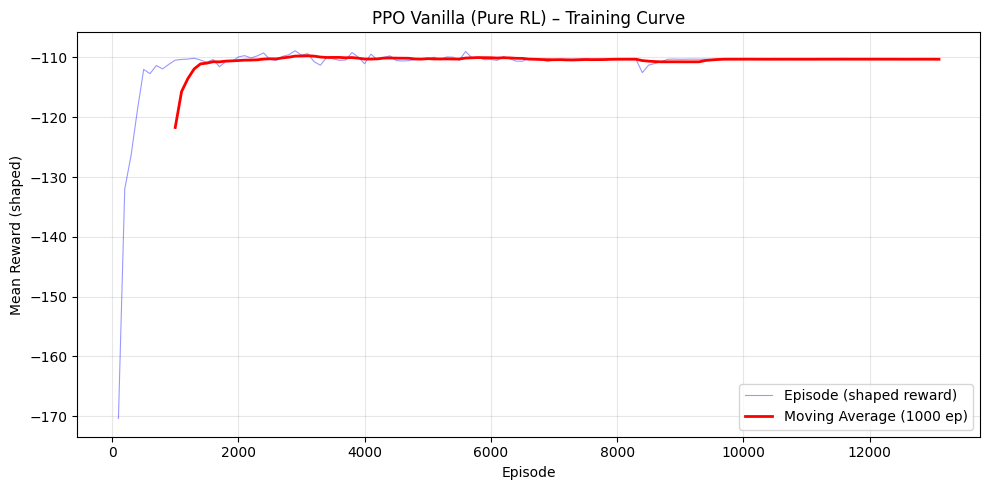

In [11]:
import re
import matplotlib.pyplot as plt
import numpy as np


raw_text = """
Ep   100 | Mean: -170.34 | Max: -114.29 | Min: -214.30 | Kill:    0 | Score:  -60.1 | Step   23816 | Time:    0.2m
Ep   200 | Mean: -132.00 | Max: -100.30 | Min: -156.28 | Kill:    0 | Score:  -21.7 | Step   45816 | Time:    0.4m
Ep   300 | Mean: -126.41 | Max:  -94.31 | Min: -154.29 | Kill:    0 | Score:  -16.1 | Step   69616 | Time:    0.6m
Ep   400 | Mean: -118.87 | Max:  -94.30 | Min: -138.31 | Kill:    0 | Score:   -8.6 | Step   91624 | Time:    0.8m
Ep   500 | Mean: -112.01 | Max:  -92.27 | Min: -130.30 | Kill:    0 | Score:   -1.7 | Step  115424 | Time:    1.1m
Ep   600 | Mean: -112.73 | Max:  -92.31 | Min: -126.30 | Kill:    0 | Score:   -2.4 | Step  137472 | Time:    1.3m
Ep   700 | Mean: -111.36 | Max:  -92.29 | Min: -122.31 | Kill:    0 | Score:   -1.1 | Step  161232 | Time:    1.4m
Ep   800 | Mean: -111.93 | Max:  -94.28 | Min: -124.31 | Kill:    0 | Score:   -1.6 | Step  183296 | Time:    1.7m
Ep   900 | Mean: -111.15 | Max:  -94.30 | Min: -118.31 | Kill:    0 | Score:   -0.9 | Step  207032 | Time:    1.9m
Ep  1000 | Mean: -110.47 | Max: -109.70 | Min: -112.31 | Kill:    0 | Score:   -0.2 | Step  229112 | Time:    2.0m
Ep  1100 | Mean: -110.35 | Max: -109.75 | Min: -112.30 | Kill:    0 | Score:   -0.1 | Step  252832 | Time:    2.3m
Ep  1200 | Mean: -110.29 | Max: -110.19 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step  274912 | Time:    2.5m
Ep  1300 | Mean: -110.15 | Max:  -92.33 | Min: -112.30 | Kill:    0 | Score:    0.1 | Step  298640 | Time:    2.7m
Ep  1400 | Mean: -110.45 | Max:  -92.28 | Min: -132.30 | Kill:    0 | Score:   -0.2 | Step  320712 | Time:    2.9m
Ep  1500 | Mean: -110.82 | Max:  -92.29 | Min: -132.29 | Kill:    0 | Score:   -0.5 | Step  344440 | Time:    3.2m
Ep  1600 | Mean: -110.36 | Max:  -92.28 | Min: -126.30 | Kill:    0 | Score:   -0.1 | Step  366512 | Time:    3.4m
Ep  1700 | Mean: -111.56 | Max:  -92.28 | Min: -126.29 | Kill:    0 | Score:   -1.3 | Step  390240 | Time:    3.6m
Ep  1800 | Mean: -110.72 | Max:  -92.29 | Min: -126.29 | Kill:    0 | Score:   -0.4 | Step  412312 | Time:    3.9m
Ep  1900 | Mean: -110.69 | Max:  -92.28 | Min: -128.30 | Kill:    0 | Score:   -0.4 | Step  436040 | Time:    4.0m
Ep  2000 | Mean: -109.93 | Max:  -92.29 | Min: -122.30 | Kill:    0 | Score:    0.4 | Step  458112 | Time:    4.2m
Ep  2100 | Mean: -109.71 | Max:  -92.30 | Min: -122.30 | Kill:    0 | Score:    0.6 | Step  481840 | Time:    4.5m
Ep  2200 | Mean: -110.11 | Max:  -92.28 | Min: -122.30 | Kill:    0 | Score:    0.2 | Step  503912 | Time:    4.6m
Ep  2300 | Mean: -109.75 | Max:  -92.29 | Min: -118.28 | Kill:    0 | Score:    0.6 | Step  527672 | Time:    4.9m
Ep  2400 | Mean: -109.26 | Max:  -92.27 | Min: -116.32 | Kill:    0 | Score:    1.0 | Step  549712 | Time:    5.1m
Ep  2500 | Mean: -110.35 | Max:  -92.29 | Min: -120.28 | Kill:    0 | Score:   -0.1 | Step  573472 | Time:    5.3m
Ep  2600 | Mean: -110.51 | Max:  -92.28 | Min: -128.28 | Kill:    0 | Score:   -0.2 | Step  595512 | Time:    5.5m
Ep  2700 | Mean: -109.84 | Max:  -92.31 | Min: -120.29 | Kill:    0 | Score:    0.5 | Step  619288 | Time:    5.7m
Ep  2800 | Mean: -109.56 | Max:  -92.29 | Min: -124.29 | Kill:    0 | Score:    0.7 | Step  641312 | Time:    5.9m
Ep  2900 | Mean: -108.89 | Max:  -92.25 | Min: -126.30 | Kill:    0 | Score:    1.4 | Step  665096 | Time:    6.1m
Ep  3000 | Mean: -109.65 | Max:  -92.00 | Min: -122.27 | Kill:    0 | Score:    0.6 | Step  687112 | Time:    6.3m
Ep  3100 | Mean: -109.38 | Max:  -92.29 | Min: -116.29 | Kill:    0 | Score:    0.9 | Step  710896 | Time:    6.6m
Ep  3200 | Mean: -110.73 | Max:  -92.29 | Min: -144.30 | Kill:    0 | Score:   -0.4 | Step  732920 | Time:    6.7m
Ep  3300 | Mean: -111.31 | Max:  -92.29 | Min: -138.31 | Kill:    0 | Score:   -1.0 | Step  756696 | Time:    7.0m
Ep  3400 | Mean: -109.99 | Max:  -92.28 | Min: -146.30 | Kill:    0 | Score:    0.3 | Step  778728 | Time:    7.2m
Ep  3500 | Mean: -110.23 | Max:  -92.28 | Min: -126.31 | Kill:    0 | Score:    0.1 | Step  802496 | Time:    7.3m
Ep  3600 | Mean: -110.51 | Max:  -92.28 | Min: -132.31 | Kill:    0 | Score:   -0.2 | Step  824528 | Time:    7.6m
Ep  3700 | Mean: -110.44 | Max:  -94.28 | Min: -130.29 | Kill:    0 | Score:   -0.2 | Step  848296 | Time:    7.8m
Ep  3800 | Mean: -109.19 | Max:  -92.30 | Min: -128.30 | Kill:    0 | Score:    1.1 | Step  870344 | Time:    8.0m
Ep  3900 | Mean: -109.97 | Max:  -92.29 | Min: -124.27 | Kill:    0 | Score:    0.3 | Step  894096 | Time:    8.2m
Ep  4000 | Mean: -111.06 | Max:  -84.29 | Min: -138.30 | Kill:    0 | Score:   -0.8 | Step  916144 | Time:    8.4m
Ep  4100 | Mean: -109.46 | Max:  -92.28 | Min: -128.30 | Kill:    0 | Score:    0.8 | Step  939896 | Time:    8.7m
Ep  4200 | Mean: -110.39 | Max:  -92.30 | Min: -116.32 | Kill:    0 | Score:   -0.1 | Step  961944 | Time:    8.9m
Ep  4300 | Mean: -110.03 | Max:  -92.28 | Min: -128.30 | Kill:    0 | Score:    0.3 | Step  985696 | Time:    9.1m
Ep  4400 | Mean: -109.75 | Max:  -92.26 | Min: -118.30 | Kill:    0 | Score:    0.5 | Step 1007744 | Time:    9.3m
Ep  4500 | Mean: -110.53 | Max:  -92.29 | Min: -136.29 | Kill:    0 | Score:   -0.2 | Step 1031496 | Time:    9.5m
Ep  4600 | Mean: -110.61 | Max:  -92.26 | Min: -124.29 | Kill:    0 | Score:   -0.3 | Step 1053544 | Time:    9.8m
Ep  4700 | Mean: -110.55 | Max:  -94.31 | Min: -118.32 | Kill:    0 | Score:   -0.3 | Step 1077296 | Time:    9.9m
Ep  4800 | Mean: -110.37 | Max:  -92.31 | Min: -124.30 | Kill:    0 | Score:   -0.1 | Step 1099344 | Time:   10.2m
Ep  4900 | Mean: -110.21 | Max:  -92.30 | Min: -118.27 | Kill:    0 | Score:    0.1 | Step 1123096 | Time:   10.4m
Ep  5000 | Mean: -110.27 | Max:  -92.29 | Min: -116.31 | Kill:    0 | Score:    0.0 | Step 1145144 | Time:   10.6m
Ep  5100 | Mean: -109.97 | Max:  -92.26 | Min: -120.31 | Kill:    0 | Score:    0.3 | Step 1168896 | Time:   10.8m
Ep  5200 | Mean: -110.41 | Max:  -92.28 | Min: -122.29 | Kill:    0 | Score:   -0.1 | Step 1190952 | Time:   11.0m
Ep  5300 | Mean: -109.93 | Max:  -92.29 | Min: -118.30 | Kill:    0 | Score:    0.4 | Step 1214704 | Time:   11.2m
Ep  5400 | Mean: -109.97 | Max:  -91.66 | Min: -118.28 | Kill:    0 | Score:    0.3 | Step 1236752 | Time:   11.4m
Ep  5500 | Mean: -110.50 | Max:  -92.31 | Min: -126.31 | Kill:    0 | Score:   -0.2 | Step 1260504 | Time:   11.6m
Ep  5600 | Mean: -109.01 | Max:  -92.23 | Min: -114.29 | Kill:    0 | Score:    1.3 | Step 1282624 | Time:   11.9m
Ep  5700 | Mean: -110.09 | Max:  -92.28 | Min: -114.29 | Kill:    0 | Score:    0.2 | Step 1306304 | Time:   12.0m
Ep  5800 | Mean: -109.98 | Max:  -92.30 | Min: -120.32 | Kill:    0 | Score:    0.3 | Step 1328424 | Time:   12.3m
Ep  5900 | Mean: -110.40 | Max:  -92.31 | Min: -122.29 | Kill:    0 | Score:   -0.1 | Step 1352112 | Time:   12.5m
Ep  6000 | Mean: -110.35 | Max:  -92.25 | Min: -124.29 | Kill:    0 | Score:   -0.1 | Step 1374256 | Time:   12.6m
Ep  6100 | Mean: -110.51 | Max: -100.30 | Min: -120.29 | Kill:    0 | Score:   -0.2 | Step 1397928 | Time:   12.9m
Ep  6200 | Mean: -109.88 | Max:  -92.27 | Min: -118.31 | Kill:    0 | Score:    0.4 | Step 1420056 | Time:   13.1m
Ep  6300 | Mean: -110.24 | Max:  -92.30 | Min: -136.28 | Kill:    0 | Score:    0.1 | Step 1443728 | Time:   13.4m
Ep  6400 | Mean: -110.63 | Max:  -92.30 | Min: -128.32 | Kill:    0 | Score:   -0.3 | Step 1465864 | Time:   13.5m
Ep  6500 | Mean: -110.65 | Max:  -94.29 | Min: -126.30 | Kill:    0 | Score:   -0.4 | Step 1489528 | Time:   13.7m
Ep  6600 | Mean: -110.19 | Max:  -92.29 | Min: -120.30 | Kill:    0 | Score:    0.1 | Step 1511664 | Time:   14.0m
Ep  6700 | Mean: -110.35 | Max:  -92.30 | Min: -122.30 | Kill:    0 | Score:   -0.1 | Step 1535328 | Time:   14.2m
Ep  6800 | Mean: -110.41 | Max:  -92.30 | Min: -116.28 | Kill:    0 | Score:   -0.1 | Step 1557464 | Time:   14.6m
Ep  6900 | Mean: -110.68 | Max:  -98.30 | Min: -122.29 | Kill:    0 | Score:   -0.4 | Step 1581128 | Time:   15.1m
Ep  7000 | Mean: -110.46 | Max: -109.73 | Min: -116.29 | Kill:    0 | Score:   -0.2 | Step 1603264 | Time:   15.5m
Ep  7100 | Mean: -110.34 | Max: -110.23 | Min: -112.31 | Kill:    0 | Score:   -0.0 | Step 1626928 | Time:   16.2m
Ep  7200 | Mean: -110.31 | Max: -110.10 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 1649064 | Time:   16.6m
Ep  7300 | Mean: -110.33 | Max: -109.71 | Min: -112.31 | Kill:    0 | Score:   -0.0 | Step 1672736 | Time:   17.3m
Ep  7400 | Mean: -110.29 | Max: -110.05 | Min: -110.33 | Kill:    0 | Score:    0.0 | Step 1694864 | Time:   17.5m
Ep  7500 | Mean: -110.29 | Max: -110.02 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 1718544 | Time:   17.7m
Ep  7600 | Mean: -110.35 | Max: -109.67 | Min: -112.30 | Kill:    0 | Score:   -0.1 | Step 1740696 | Time:   17.9m
Ep  7700 | Mean: -110.31 | Max: -109.97 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 1764344 | Time:   18.1m
Ep  7800 | Mean: -110.31 | Max: -110.15 | Min: -112.17 | Kill:    0 | Score:   -0.0 | Step 1786496 | Time:   18.3m
Ep  7900 | Mean: -110.33 | Max: -110.05 | Min: -112.32 | Kill:    0 | Score:   -0.0 | Step 1810144 | Time:   18.5m
Ep  8000 | Mean: -110.30 | Max: -109.73 | Min: -112.29 | Kill:    0 | Score:   -0.0 | Step 1832296 | Time:   18.7m
Ep  8100 | Mean: -110.29 | Max: -109.98 | Min: -110.33 | Kill:    0 | Score:    0.0 | Step 1855944 | Time:   18.9m
Ep  8200 | Mean: -110.31 | Max: -109.73 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 1878096 | Time:   19.1m
Ep  8300 | Mean: -110.33 | Max: -109.97 | Min: -114.30 | Kill:    0 | Score:   -0.0 | Step 1901744 | Time:   19.4m
Ep  8400 | Mean: -112.55 | Max:  -96.30 | Min: -134.28 | Kill:    0 | Score:   -2.3 | Step 1923896 | Time:   19.6m
Ep  8500 | Mean: -111.29 | Max:  -96.29 | Min: -140.30 | Kill:    0 | Score:   -1.0 | Step 1947544 | Time:   19.7m
Ep  8600 | Mean: -111.03 | Max:  -96.28 | Min: -128.30 | Kill:    0 | Score:   -0.7 | Step 1969696 | Time:   20.0m
Ep  8700 | Mean: -110.73 | Max: -110.22 | Min: -124.28 | Kill:    0 | Score:   -0.4 | Step 1993344 | Time:   20.2m
Ep  8800 | Mean: -110.33 | Max: -110.14 | Min: -112.28 | Kill:    0 | Score:   -0.0 | Step 2015496 | Time:   20.4m
Ep  8900 | Mean: -110.29 | Max: -110.06 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 2039144 | Time:   20.6m
Ep  9000 | Mean: -110.33 | Max: -110.18 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2061296 | Time:   20.8m
Ep  9100 | Mean: -110.31 | Max: -109.99 | Min: -112.03 | Kill:    0 | Score:   -0.0 | Step 2084952 | Time:   21.0m
Ep  9200 | Mean: -110.29 | Max: -109.97 | Min: -110.33 | Kill:    0 | Score:    0.0 | Step 2107096 | Time:   21.2m
Ep  9300 | Mean: -110.31 | Max: -110.08 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2130760 | Time:   21.5m
Ep  9400 | Mean: -110.30 | Max: -110.26 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 2152896 | Time:   21.6m
Ep  9500 | Mean: -110.35 | Max: -109.98 | Min: -112.30 | Kill:    0 | Score:   -0.1 | Step 2176560 | Time:   21.8m
Ep  9600 | Mean: -110.29 | Max: -109.74 | Min: -110.33 | Kill:    0 | Score:    0.0 | Step 2198696 | Time:   22.0m
Ep  9700 | Mean: -110.33 | Max: -109.73 | Min: -112.31 | Kill:    0 | Score:   -0.0 | Step 2222360 | Time:   22.2m
Ep  9800 | Mean: -110.29 | Max: -110.04 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 2244512 | Time:   22.4m
Ep  9900 | Mean: -110.31 | Max: -110.02 | Min: -112.29 | Kill:    0 | Score:   -0.0 | Step 2268160 | Time:   22.6m
Ep 10000 | Mean: -110.29 | Max: -110.03 | Min: -110.31 | Kill:    0 | Score:    0.0 | Step 2290320 | Time:   22.8m
Ep 10100 | Mean: -110.30 | Max: -110.22 | Min: -110.33 | Kill:    0 | Score:    0.0 | Step 2313960 | Time:   23.0m
Ep 10200 | Mean: -110.35 | Max: -110.12 | Min: -112.31 | Kill:    0 | Score:   -0.1 | Step 2336120 | Time:   23.2m
Ep 10300 | Mean: -110.33 | Max: -110.07 | Min: -112.32 | Kill:    0 | Score:   -0.0 | Step 2359760 | Time:   23.4m
Ep 10400 | Mean: -110.33 | Max: -109.70 | Min: -112.29 | Kill:    0 | Score:   -0.0 | Step 2381920 | Time:   23.6m
Ep 10500 | Mean: -110.31 | Max: -110.11 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2405568 | Time:   23.7m
Ep 10600 | Mean: -110.31 | Max: -109.70 | Min: -112.31 | Kill:    0 | Score:   -0.0 | Step 2427720 | Time:   24.0m
Ep 10700 | Mean: -110.30 | Max: -109.68 | Min: -112.29 | Kill:    0 | Score:   -0.0 | Step 2451376 | Time:   24.2m
Ep 10800 | Mean: -110.31 | Max: -110.04 | Min: -112.29 | Kill:    0 | Score:   -0.0 | Step 2473520 | Time:   24.4m
Ep 10900 | Mean: -110.31 | Max: -110.11 | Min: -112.32 | Kill:    0 | Score:   -0.0 | Step 2497176 | Time:   24.6m
Ep 11000 | Mean: -110.29 | Max: -110.25 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 2519320 | Time:   24.8m
Ep 11100 | Mean: -110.31 | Max: -110.00 | Min: -112.31 | Kill:    0 | Score:   -0.0 | Step 2542976 | Time:   25.1m
Ep 11200 | Mean: -110.29 | Max: -109.95 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 2565128 | Time:   25.3m
Ep 11300 | Mean: -110.31 | Max: -109.65 | Min: -112.29 | Kill:    0 | Score:   -0.0 | Step 2588776 | Time:   25.5m
Ep 11400 | Mean: -110.33 | Max: -110.10 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2610928 | Time:   25.7m
Ep 11500 | Mean: -110.29 | Max: -109.98 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 2634584 | Time:   25.9m
Ep 11600 | Mean: -110.28 | Max: -109.65 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 2656728 | Time:   26.1m
Ep 11700 | Mean: -110.33 | Max: -109.66 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2680384 | Time:   26.3m
Ep 11800 | Mean: -110.31 | Max: -110.00 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2702528 | Time:   26.5m
Ep 11900 | Mean: -110.31 | Max: -110.10 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2726200 | Time:   26.8m
Ep 12000 | Mean: -110.31 | Max: -109.73 | Min: -112.28 | Kill:    0 | Score:   -0.0 | Step 2748328 | Time:   26.9m
Ep 12100 | Mean: -110.29 | Max: -110.22 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 2772000 | Time:   27.2m
Ep 12200 | Mean: -110.31 | Max: -110.08 | Min: -112.29 | Kill:    0 | Score:   -0.0 | Step 2794128 | Time:   27.4m
Ep 12300 | Mean: -110.33 | Max: -110.00 | Min: -112.29 | Kill:    0 | Score:   -0.0 | Step 2817800 | Time:   27.5m
Ep 12400 | Mean: -110.31 | Max: -110.17 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2839928 | Time:   27.8m
Ep 12500 | Mean: -110.33 | Max: -110.05 | Min: -112.33 | Kill:    0 | Score:   -0.0 | Step 2863616 | Time:   27.9m
Ep 12600 | Mean: -110.31 | Max: -110.03 | Min: -112.28 | Kill:    0 | Score:   -0.0 | Step 2885728 | Time:   28.2m
Ep 12700 | Mean: -110.31 | Max: -110.08 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2909416 | Time:   28.4m
Ep 12800 | Mean: -110.29 | Max: -109.96 | Min: -110.32 | Kill:    0 | Score:    0.0 | Step 2931528 | Time:   28.5m
Ep 12900 | Mean: -110.31 | Max: -109.65 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2955216 | Time:   28.8m
Ep 13000 | Mean: -110.33 | Max: -110.08 | Min: -112.30 | Kill:    0 | Score:   -0.0 | Step 2977328 | Time:   28.9m
Ep 13100 | Mean: -110.35 | Max: -110.15 | Min: -112.29 | Kill:    0 | Score:   -0.1 | Step 3001016 | Time:   29.2m
"""

# Parse the log
pattern = r"Ep\s+(\d+)\s+\|\s+Mean:\s+([-\d.]+)"
matches = re.findall(pattern, raw_text)

episodes = [int(m[0]) for m in matches]
mean_rewards = [float(m[1]) for m in matches]

# Convert to numpy arrays
episodes = np.array(episodes)
mean_rewards = np.array(mean_rewards)

# Create training curve plot
plt.figure(figsize=(10, 5))
plt.plot(episodes, mean_rewards, alpha=0.4, linewidth=0.8, color='blue', label='Episode (shaped reward)')

# Moving average (window = 10, i.e., 1000 episodes)
window = 10
if len(mean_rewards) >= window:
    ma = np.convolve(mean_rewards, np.ones(window)/window, mode='valid')
    plt.plot(episodes[window-1:], ma, color='red', linewidth=2, label=f'Moving Average ({window*100} ep)')

plt.xlabel('Episode')
plt.ylabel('Mean Reward (shaped)')
plt.title('PPO Vanilla (Pure RL) – Training Curve')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('ppo_vanilla_training.png', dpi=150)
plt.show()

# Final evaluation: 10 episodes & best‑episode video 

In [2]:
# =============================================================
# Cell: PPO Vanilla Evaluation (10 episodes + TensorBoard + Video)
# =============================================================
import time
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from torch.utils.tensorboard import SummaryWriter
from gymnasium.wrappers import RecordVideo

MODEL_PATH = "models/PPO_vanilla/final"
LOG_DIR    = "runs/PPO_vanilla_eval"
VIDEO_DIR  = "videos/PPO_vanilla_best"
NUM_EPS    = 10

model = PPO.load(MODEL_PATH)
writer = SummaryWriter(LOG_DIR)

# Phase 1 – evaluate with fixed seeds, store seed for each episode
results = []          # (total_reward, final_score, kills, steps, seed)
print(f"Evaluating PPO Vanilla – {NUM_EPS} episodes …\n")
for ep in range(NUM_EPS):
    ep_seed = 6000 + ep          # another seed range to keep things independent
    env = gym.make("Shooter-v0", render_mode=None)
    obs, info = env.reset(seed=ep_seed)
    total_reward, ep_kills = 0.0, 0
    prev_score = info["hunterScore"]

    while True:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        score_delta = info["hunterScore"] - prev_score
        if score_delta > 0:
            ep_kills += 1
        prev_score = info["hunterScore"]
        if terminated or truncated:
            break
    env.close()

    final_score = info["hunterScore"]
    steps = info["tick"]
    results.append((total_reward, final_score, ep_kills, steps, ep_seed))

    # Log each episode to TensorBoard
    writer.add_scalar("Episode/Reward", total_reward, ep)
    writer.add_scalar("Episode/Score",  final_score,  ep)
    writer.add_scalar("Episode/Kills",  ep_kills,     ep)
    writer.add_scalar("Episode/Steps",  steps,        ep)

# Convert to numpy arrays for analysis
arr_rewards = np.array([r[0] for r in results])
arr_scores  = np.array([r[1] for r in results])
arr_kills   = np.array([r[2] for r in results])
arr_steps   = np.array([r[3] for r in results])

best_reward_idx = np.argmax(arr_rewards)
best_score_idx  = np.argmax(arr_scores)
best_kill_idx   = np.argmax(arr_kills)

# Print summary table
print("─" * 60)
print(f"{'Ep':>4s} | {'Reward':>10s} | {'Score':>6s} | {'Kills':>5s} | {'Steps':>5s} | {'Seed':>5s}")
print("─" * 60)
for i in range(NUM_EPS):
    print(f"{i+1:4d} | {arr_rewards[i]:10.2f} | {arr_scores[i]:6d} | {arr_kills[i]:5d} | {arr_steps[i]:5d} | {results[i][4]:5d}")
print("─" * 60)
print(f"Best Reward : episode {best_reward_idx+1:2d}  with reward = {arr_rewards[best_reward_idx]:.2f}  (seed {results[best_reward_idx][4]})")
print(f"Best Score  : episode {best_score_idx+1:2d}  with score  = {arr_scores[best_score_idx]}  (seed {results[best_score_idx][4]})")
print(f"Best Kills  : episode {best_kill_idx+1:2d}  with kills  = {arr_kills[best_kill_idx]}  (seed {results[best_kill_idx][4]})")
print("─" * 60)

# Log overall summary scalars
writer.add_scalar("Summary/Mean_Reward", np.mean(arr_rewards))
writer.add_scalar("Summary/Std_Reward",  np.std(arr_rewards))
writer.add_scalar("Summary/Mean_Score",  np.mean(arr_scores))
writer.add_scalar("Summary/Mean_Kills",  np.mean(arr_kills))

# Phase 2 – record the exact episode with the BEST SCORE
chosen_ep = best_score_idx               # best score, not reward
best_seed = results[chosen_ep][4]
print(f"\nRecording episode {chosen_ep+1} (best score) with seed={best_seed} (score will be {arr_scores[chosen_ep]}) …")

# Create a fresh environment with the RecordVideo wrapper
env = gym.make("Shooter-v0", render_mode="rgb_array")
env = RecordVideo(
    env, VIDEO_DIR,
    episode_trigger=lambda ep_id: ep_id == 0   # record the very first episode
)
obs, info = env.reset(seed=best_seed)          # same seed as Phase 1 ⇒ identical episode

while True:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break
env.close()

writer.close()
print(f"\nVideo saved in '{VIDEO_DIR}'.")
print(f"Run `tensorboard --logdir runs` to view logs.")

/home/paradorn00/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Evaluating PPO Vanilla – 10 episodes …

────────────────────────────────────────────────────────────
  Ep |     Reward |  Score | Kills | Steps |  Seed
────────────────────────────────────────────────────────────
   1 |    -110.30 |      0 |     0 |   229 |  6000
   2 |    -110.31 |      0 |     0 |   229 |  6001
   3 |    -110.31 |      0 |     0 |   229 |  6002
   4 |    -110.29 |      0 |     0 |   229 |  6003
   5 |    -110.30 |      0 |     0 |   229 |  6004
   6 |    -110.30 |      0 |     0 |   229 |  6005
   7 |    -110.30 |      0 |     0 |   229 |  6006
   8 |    -110.29 |      0 |     0 |   229 |  6007
   9 |    -110.29 |      0 |     0 |   229 |  6008
  10 |    -110.29 |      0 |     0 |   229 |  6009
────────────────────────────────────────────────────────────
Best Reward : episode  4  with reward = -110.29  (seed 6003)
Best Score  : episode  1  with score  = 0  (seed 6000)
Best Kills  : episode  1  with kills  = 0  (seed 6000)
─────────────────────────────────────────────

/home/paradorn00/miniconda3/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /mnt/c/Users/lenovo/Desktop/FOR AIT HOMEWORK/2_Y1 SEM 2/Deep learning/Final Project/project/videos/PPO_vanilla_best folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Video saved in 'videos/PPO_vanilla_best'.
Run `tensorboard --logdir runs` to view logs.


In [13]:
pip install tensorboard

Note: you may need to restart the kernel to use updated packages.


In [ ]:
!tensorboard --logdir runs

/home/paradorn00/miniconda3/lib/python3.13/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)
